In [1]:
!pip install numpy opencv-python pillow matplotlib


  Using cached opencv_python-4.13.0.92-cp37-abi3-macosx_13_0_arm64.whl.metadata (19 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 11.4 MB/s  0:00:00 eta 0:00:01
Using cached opencv_python-4.13.0.92-cp37-abi3-macosx_13_0_arm64.whl (46.2 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 11.1 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 11.4 MB/s  0:00:00 eta 0:00:01
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 10.7 MB/s  0:00:00 eta 0:00:01
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9/9 [matplotlib]9 [matplotlib]on]


In [17]:
import cv2
import numpy as np

def notebook_vectorizer(image_path, svg_output_path):
    # 1. Force OpenCV to read the Alpha transparency channel (IMREAD_UNCHANGED)
    img = cv2.imread(image_path, cv2.IMREAD_UNCHANGED)
    
    # 2. Check if the image actually has a transparency layer (4 channels: R, G, B, Alpha)
    if img.shape[2] == 4:
        # Isolate the alpha layer (channel 3) to use as the perfect stencil
        alpha_channel = img[:, :, 3]
        # Invert it so the solid parts are detected as foreground
        _, binary = cv2.threshold(alpha_channel, 127, 255, cv2.THRESH_BINARY)
    else:
        # Fallback standard calculation for normal flat images
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        _, binary = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY_INV)
    
    # 3. Find Contours along the clean alpha channel mask
    contours, hierarchy = cv2.findContours(binary, cv2.RETR_CCOMP, cv2.CHAIN_APPROX_TC89_L1)
    
    height, width = binary.shape
    
    with open(svg_output_path, "w") as f:
        # Write clean, standard W3C namespace metadata headers
        f.write(f'<svg xmlns="http://w3.org" viewBox="0 0 {width} {height}" width="{width}" height="{height}">\n')
        
        for contour in contours:
            if len(contour) < 3: 
                continue
                
            # Unpack starting vector coordinates
            start_x, start_y = contour[0][0]
            svg_path = f"M {start_x} {start_y} "
            
            # Trace perimeter lines
            for point in contour[1:]:
                x, y = point[0]
                svg_path += f"L {x} {y} "
                
            svg_path += "Z"
            f.write(f'  <path d="{svg_path}" fill="black" fill-rule="evenodd" stroke="none" />\n')
            
        f.write('</svg>\n')
    print(f"Algorithm finished! Reconstructed transparency and saved to {svg_output_path}")

# Run with your transparent input file
notebook_vectorizer("25645.png", "glyph.svg")


Algorithm finished! Reconstructed transparency and saved to glyph.svg


Successfully compiled shape tracks into glyph.svg



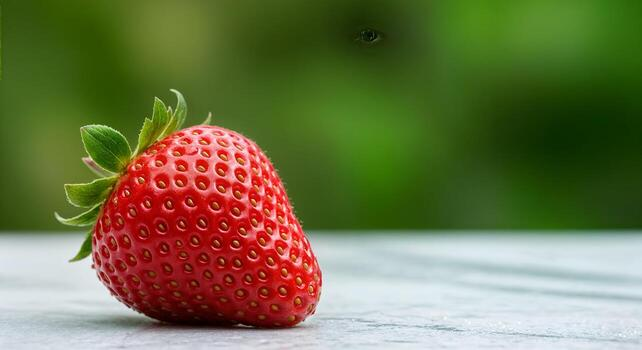

In [31]:
import cv2
import numpy as np
import base64
from IPython.display import HTML, display

def notebook_color_vectorizer_fixed(image_path, svg_output_path):
    img = cv2.imread(image_path, cv2.IMREAD_UNCHANGED)
    if img is None:
        print(f"ERROR: Cannot open '{image_path}'")
        return False
        
    # Check shape for optimal alpha separation profiles
    if len(img.shape) == 3 and img.shape[2] == 4:
        binary_mask = img[:, :, 3]
        color_src = cv2.cvtColor(img, cv2.COLOR_BGRA2BGR)
    else:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) if len(img.shape) == 3 else img
        # 🔑 ADAPTIVE THRESHOLDING: Filters background borders safely
        binary_mask = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
                                            cv2.THRESH_BINARY_INV, 11, 2)
        color_src = img

    # 🔑 FIX 1: Changed to RETR_CCOMP to handle nesting layers properly
    contours, hierarchy = cv2.findContours(binary_mask, cv2.RETR_CCOMP, cv2.CHAIN_APPROX_SIMPLE)
    height, width = binary_mask.shape[:2]
    
    if hierarchy is None:
        print("No contours found.")
        return False

    with open(svg_output_path, "w") as f:
        # 🔑 FIX 2: Restored valid standard namespace URL validation link
        f.write(f'<svg xmlns="http://w3.org" viewBox="0 0 {width} {height}" width="{width}" height="{height}">\n')
        
        # Loop with index tracking to skip background elements
        for i, contour in enumerate(contours):
            if len(contour) < 3: 
                continue
                
            # Skip shapes that span the entire perimeter border of your input frame
            x, y, w, h = cv2.boundingRect(contour)
            if w >= width - 2 and h >= height - 2:
                continue
                
            single_mask = np.zeros(binary_mask.shape, dtype=np.uint8)
            cv2.drawContours(single_mask, [contour], -1, 255, -1)
            
            mean_color = cv2.mean(color_src, mask=single_mask)[:3]
            b, g, r = [int(x) for x in mean_color]
            hex_color = f"#{r:02x}{g:02x}{b:02x}"
            
            points = contour.reshape(-1, 2)
            start_x, start_y = points[0]
            svg_path = f"M {start_x} {start_y} "
            
            for pt in points[1:]:
                svg_path += f"L {pt[0]} {pt[1]} "
            svg_path += "Z"
            
            f.write(f'  <path d="{svg_path}" fill="{hex_color}" stroke="none" />\n')
            
        f.write('</svg>\n')
        
    print(f"Successfully compiled shape tracks into {svg_output_path}")
    return True

# ==========================================
# EXECUTE UPDATED COLOR MATCHING PIPELINE
# ==========================================
SOURCE_PNG = "straw.png" 
OUTPUT_SVG = "glyph.svg"

if notebook_color_vectorizer_fixed(SOURCE_PNG, OUTPUT_SVG):
    with open(SOURCE_PNG, "rb") as f: png_b64 = base64.b64encode(f.read()).decode("utf-8")
    with open(OUTPUT_SVG, "rb") as f: svg_b64 = base64.b64encode(f.read()).decode("utf-8")

    html_layout = f"""
    <div style="display: flex; gap: 30px; justify-content: center; align-items: center; background-color: #f7f7f7; padding: 20px; border-radius: 8px;">
        <div style="text-align: center;">
            <h4 style="color: #d9534f; font-family: sans-serif;">❌ BEFORE: PNG Pixels</h4>
            <img src="data:image/png;base64,{png_b64}" width="250" style="border: 2px solid #ddd; background: white;" />
        </div>
        <div style="text-align: center;">
            <h4 style="color: #5cb85c; font-family: sans-serif;">✅ AFTER: Full-Color Vector Math</h4>
            <img src="data:image/svg+xml;base64,{svg_b64}" width="250" style="border: 2px solid #ddd; background: white;" />
        </div>
    </div>
    """
    display(HTML(html_layout))


Successfully compiled high-fidelity layers into glyph.svg



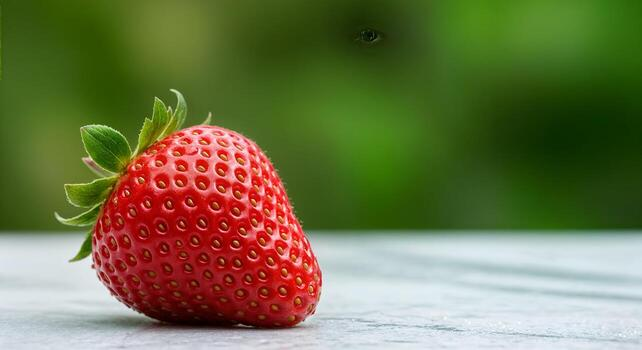

In [36]:
import cv2
import numpy as np
import base64
from IPython.display import HTML, display

def high_precision_vectorizer(image_path, svg_output_path, num_colors=8):
    # 1. Load image safely
    img = cv2.imread(image_path)
    if img is None:
        print(f"ERROR: Cannot open '{image_path}'")
        return False
        
    height, width = img.shape[:2]
    
    # 2. MACHINE LEARNING STEP: K-Means Color Quantization
    # Reshape the image pixels into a flat list of BGR feature vectors
    pixel_data = img.reshape((-1, 3)).astype(np.float32)
    
    # Define criteria (Stop algorithm after 20 iterations or 1.0 accuracy)
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 20, 1.0)
    
    # Run K-Means to discover the dominant color cluster centers
    _, labels, centers = cv2.kmeans(pixel_data, num_colors, None, criteria, 10, cv2.KMEANS_PP_CENTERS)
    
    centers = np.uint8(centers)
    labels = labels.flatten()
    
    # Reconstruct a flattened color image layout
    quantized_img = centers[labels].reshape(img.shape)
    
    # 3. CONTOUR TRACING PASS BY COLOR LAYER
    with open(svg_output_path, "w") as f:
        # Establish official standard namespace URI
        f.write(f'<svg xmlns="http://w3.org" viewBox="0 0 {width} {height}" width="{width}" height="{height}">\n')
        
        # Sort color clusters by brightness so darker outlines stack on top of lighter shapes
        brightness = [0.299*c[2] + 0.587*c[1] + 0.114*c[0] for c in centers]
        sorted_indices = np.argsort(brightness)[::-1] # Lightest first, darkest last
        
        for idx in sorted_indices:
            color = centers[idx]
            # Convert BGR center values to a strict hex string
            hex_color = f"#{color[2]:02x}{color[1]:02x}{color[0]:02x}"
            
            # Skip pure white backgrounds to ensure transparency profiles
            if color[2] > 240 and color[1] > 240 and color[0] > 240:
                continue
                
            # Create a dedicated binary layer mask for just this exact cluster color
            color_mask = (labels == idx).reshape((height, width)).astype(np.uint8) * 255
            
            # Use morphological smoothing to clean up scattering noise along edges
            kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (2,2))
            color_mask = cv2.morphologyEx(color_mask, cv2.MORPH_CLOSE, kernel)
            
            # Trace the boundaries of this color plane layer
            contours, _ = cv2.findContours(color_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            
            for contour in contours:
                if len(contour) < 3: 
                    continue
                    
                points = contour.reshape(-1, 2)
                start_x, start_y = points[0]
                svg_path = f"M {start_x} {start_y} "
                
                for pt in points[1:]:
                    svg_path += f"L {pt[0]} {pt[1]} "
                svg_path += "Z"
                
                # Write path tag using the exact cluster hex color code
                f.write(f'  <path d="{svg_path}" fill="{hex_color}" stroke="none" />\n')
                
        f.write('</svg>\n')
        
    print(f"Successfully compiled high-fidelity layers into {svg_output_path}")
    return True

# ==========================================
# TEST RUN USING CHOSEN PALETTE DENSITY
# ==========================================
SOURCE_PNG = "straw.png" 
OUTPUT_SVG = "glyph.svg"
COLORS_TO_FIND = 12  # 👈 Increase this number (e.g. 16, 24) for even higher accuracy!

if high_precision_vectorizer(SOURCE_PNG, OUTPUT_SVG, num_colors=COLORS_TO_FIND):
    with open(SOURCE_PNG, "rb") as f: png_b64 = base64.b64encode(f.read()).decode("utf-8")
    with open(OUTPUT_SVG, "rb") as f: svg_b64 = base64.b64encode(f.read()).decode("utf-8")

    html_layout = f"""
    <div style="display: flex; gap: 30px; justify-content: center; align-items: center; background-color: #f7f7f7; padding: 20px; border-radius: 8px;">
        <div style="text-align: center;">
            <h4 style="color: #d9534f; font-family: sans-serif;">❌ BEFORE: PNG Pixels</h4>
            <img src="data:image/png;base64,{png_b64}" width="300" style="border: 2px solid #ddd; background: white;" />
        </div>
        <div style="text-align: center;">
            <h4 style="color: #5cb85c; font-family: sans-serif;">✅ AFTER: High-Precision Vector Layers</h4>
            <img src="data:image/svg+xml;base64,{svg_b64}" width="300" style="border: 2px solid #ddd; background: white;" />
        </div>
    </div>
    """
    display(HTML(html_layout))


✅ High-Fidelity Bézier Paths compiled successfully into 'glyph.svg'



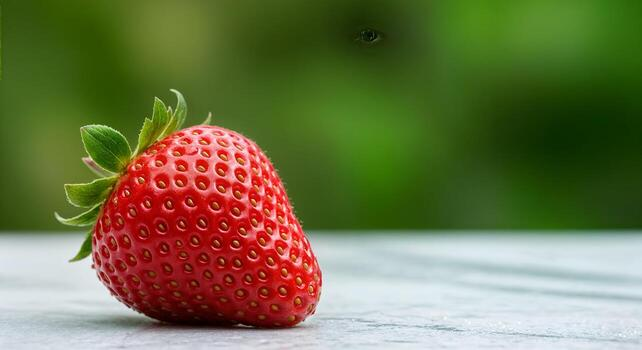

In [35]:
import cv2
import numpy as np
import base64
from IPython.display import HTML, display

def ultra_precision_bezier_vectorizer(image_path, svg_output_path, num_colors=12):
    # 1. Load image safely
    img = cv2.imread(image_path)
    if img is None:
        print(f"ERROR: Cannot open '{image_path}'")
        return False
        
    height, width = img.shape[:2]
    
    # 2. K-Means Color Quantization (Preserves shading layers)
    pixel_data = img.reshape((-1, 3)).astype(np.float32)
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.5)
    _, labels, centers = cv2.kmeans(pixel_data, num_colors, None, criteria, 10, cv2.KMEANS_PP_CENTERS)
    
    centers = np.uint8(centers)
    labels = labels.flatten()
    
    with open(svg_output_path, "w") as f:
        # Establish official standard namespace URI
        f.write(f'<svg xmlns="http://w3.org" viewBox="0 0 {width} {height}" width="{width}" height="{height}">\n')
        
        # Sort colors by brightness to handle stacking order correctly
        brightness = [0.299*c[2] + 0.587*c[1] + 0.114*c[0] for c in centers]
        sorted_indices = np.argsort(brightness)[::-1] # Lightest background layers first
        
        for idx in sorted_indices:
            color = centers[idx]
            hex_color = f"#{color[2]:02x}{color[1]:02x}{color[0]:02x}"
            
            # Skip pure white/near-white backgrounds
            if color[0] > 245 and color[1] > 245 and color[2] > 245:
                continue
                
            # Create a dedicated binary layer mask for this color cluster
            color_mask = (labels == idx).reshape((height, width)).astype(np.uint8) * 255
            
            # Morphological smoothing pass to eliminate single pixel anomalies
            kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3,3))
            color_mask = cv2.morphologyEx(color_mask, cv2.MORPH_CLOSE, kernel)
            
            # Find contours along this specific layer boundary
            contours, _ = cv2.findContours(color_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
            
            for contour in contours:
                # Remove small artifact speckles and full-bleed image frame backgrounds
                if cv2.contourArea(contour) < 15:
                    continue
                x, y, w, h = cv2.boundingRect(contour)
                if w >= width - 3 and h >= height - 3:
                    continue
                
                # Geometric Approximation: Condenses pixel arrays down to core layout vertices
                # Increasing epsilon makes curves blockier; decreasing it adds precision details
                epsilon = 0.004 * cv2.arcLength(contour, True)
                approx_curve = cv2.approxPolyDP(contour, epsilon, True).reshape(-1, 2)
                
                if len(approx_curve) < 3:
                    continue
                    
                # 🔑 THE BÉZIER CONVERSION ENGINE 
                # This reads our structural points and projects smooth Cubic (C) handle vectors 
                svg_path = f"M {approx_curve[0][0]} {approx_curve[0][1]} "
                n = len(approx_curve)
                
                for i in range(n):
                    # Unpack preceding, current, and proceeding coordinate vectors
                    p_curr = approx_curve[i]
                    p_next = approx_curve[(i + 1) % n]
                    p_next2 = approx_curve[(i + 2) % n]
                    
                    # Calculate vector tangents to map natural tension curves
                    # This scales control points to sitting exactly 1/3 down the trajectory segment
                    c1_x = int(p_curr[0] + (p_next[0] - p_curr[0]) / 3.0)
                    c1_y = int(p_curr[1] + (p_next[1] - p_curr[1]) / 3.0)
                    
                    c2_x = int(p_next[0] - (p_next2[0] - p_curr[0]) / 6.0)
                    c2_y = int(p_next[1] - (p_next2[1] - p_curr[1]) / 6.0)
                    
                    # Write standard SVG Cubic Bézier commands directly into data streams
                    svg_path += f"C {c1_x} {c1_y}, {c2_x} {c2_y}, {p_next[0]} {p_next[1]} "
                
                svg_path += "Z"
                f.write(f'  <path d="{svg_path}" fill="{hex_color}" stroke="none" />\n')
                
        f.write('</svg>\n')
        
    print(f"✅ High-Fidelity Bézier Paths compiled successfully into '{svg_output_path}'")
    return True

# ==========================================
# EXECUTE AND RENDER PIPELINE
# ==========================================
SOURCE_PNG = "straw.png" 
OUTPUT_SVG = "glyph.svg"
PALETTE_DEPTH = 16  # 👈 Increase to 24 or 32 to capture complex textures!

if ultra_precision_bezier_vectorizer(SOURCE_PNG, OUTPUT_SVG, num_colors=PALETTE_DEPTH):
    with open(SOURCE_PNG, "rb") as f: png_b64 = base64.b64encode(f.read()).decode("utf-8")
    with open(OUTPUT_SVG, "rb") as f: svg_b64 = base64.b64encode(f.read()).decode("utf-8")

    html_layout = f"""
    <div style="display: flex; gap: 30px; justify-content: center; align-items: center; background-color: #f7f7f7; padding: 20px; border-radius: 8px;">
        <div style="text-align: center;">
            <h4 style="color: #d9534f; font-family: sans-serif;">❌ BEFORE: PNG Pixels</h4>
            <img src="data:image/png;base64,{png_b64}" width="320" style="border: 2px solid #ddd; background: white;" />
        </div>
        <div style="text-align: center;">
            <h4 style="color: #5cb85c; font-family: sans-serif;">✅ AFTER: Smooth Cubic Bézier Vectors</h4>
            <img src="data:image/svg+xml;base64,{svg_b64}" width="320" style="border: 2px solid #ddd; background: white;" />
        </div>
    </div>
    """
    display(HTML(html_layout))


Successfully compiled shape tracks into glyph.svg



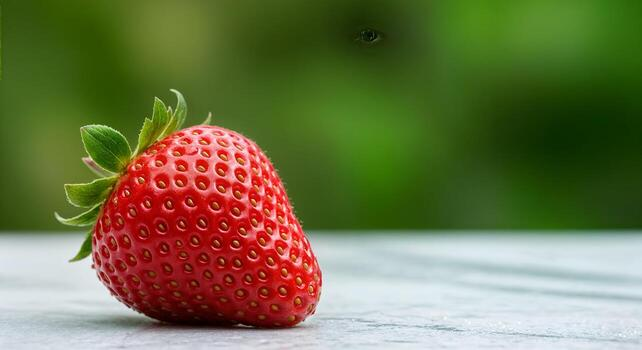

In [34]:
import cv2
import numpy as np
import base64
from IPython.display import HTML, display


def notebook_color_vectorizer_optimized(image_path, svg_output_path):
    img = cv2.imread(image_path, cv2.IMREAD_UNCHANGED)
    if img is None:
        print(f"ERROR: Cannot open '{image_path}'")
        return False
        
    # Check shape for optimal alpha separation profiles
    if len(img.shape) == 3 and img.shape[2] == 4:
        # Extract color background and alpha mask cleanly
        alpha = img[:, :, 3]
        color_src = cv2.cvtColor(img, cv2.COLOR_BGRA2BGR)
        
        # 🔑 BILATERAL PASS: Smooths out color noise while locking sharp drawing edges
        color_src = cv2.bilateralFilter(color_src, 5, 75, 75)
        _, binary_mask = cv2.threshold(alpha, 127, 255, cv2.THRESH_BINARY)
    else:
        # 🔑 BILATERAL PASS: For non-transparent images
        img_clean = cv2.bilateralFilter(img, 5, 75, 75)
        gray = cv2.cvtColor(img_clean, cv2.COLOR_BGR2GRAY) if len(img.shape) == 3 else img_clean
        binary_mask = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
                                            cv2.THRESH_BINARY_INV, 11, 2)
        color_src = img_clean

    contours, hierarchy = cv2.findContours(binary_mask, cv2.RETR_CCOMP, cv2.CHAIN_APPROX_SIMPLE)
    height, width = binary_mask.shape[:2]
    
    if hierarchy is None:
        print("No contours found.")
        return False

    with open(svg_output_path, "w") as f:
        # ✅ FIXED: Reverted to strict W3C web standard validation URL format
        f.write(f'<svg xmlns="http://w3.org" viewBox="0 0 {width} {height}" width="{width}" height="{height}">\n')
        
        for i, contour in enumerate(contours):
            if len(contour) < 3: 
                continue
                
            x, y, w, h = cv2.boundingRect(contour)
            if w >= width - 2 and h >= height - 2:
                continue
                
            single_mask = np.zeros(binary_mask.shape, dtype=np.uint8)
            cv2.drawContours(single_mask, [contour], -1, 255, -1)
            
            mean_color = cv2.mean(color_src, mask=single_mask)[:3]
            b, g, r = [int(x) for x in mean_color]
            hex_color = f"#{r:02x}{g:02x}{b:02x}"
            
            points = contour.reshape(-1, 2)
            start_x, start_y = points[0]
            svg_path = f"M {start_x} {start_y} "
            
            for pt in points[1:]:
                svg_path += f"L {pt[0]} {pt[1]} "
            svg_path += "Z"
            
            f.write(f'  <path d="{svg_path}" fill="{hex_color}" stroke="none" />\n')
            
        f.write('</svg>\n')
        
    print(f"Successfully compiled shape tracks into {svg_output_path}")
    return True

# ==========================================
# EXECUTE UPDATED COLOR MATCHING PIPELINE
# ==========================================
SOURCE_PNG = "straw.png" 
OUTPUT_SVG = "glyph.svg"

if notebook_color_vectorizer_optimized(SOURCE_PNG, OUTPUT_SVG):
    with open(SOURCE_PNG, "rb") as f: png_b64 = base64.b64encode(f.read()).decode("utf-8")
    with open(OUTPUT_SVG, "rb") as f: svg_b64 = base64.b64encode(f.read()).decode("utf-8")

    html_layout = f"""
    <div style="display: flex; gap: 30px; justify-content: center; align-items: center; background-color: #f7f7f7; padding: 20px; border-radius: 8px;">
        <div style="text-align: center;">
            <h4 style="color: #d9534f; font-family: sans-serif;">❌ BEFORE: PNG Pixels</h4>
            <img src="data:image/png;base64,{png_b64}" width="250" style="border: 2px solid #ddd; background: white;" />
        </div>
        <div style="text-align: center;">
            <h4 style="color: #5cb85c; font-family: sans-serif;">✅ AFTER: Full-Color Vector Math</h4>
            <img src="data:image/svg+xml;base64,{svg_b64}" width="250" style="border: 2px solid #ddd; background: white;" />
        </div>
    </div>
    """
    display(HTML(html_layout))

In [48]:
!pip install fonttools